# Quantum-Inspired Digital Watermarking for Forensic Evidence Authentication Using SARG04 Protocol

## Stage 1: Secure Key Generation Using SARG04

This notebook demonstrates secure key generation using the SARG04 Quantum Key Distribution protocol.

Objectives:

- Simulate Alice and Bob communication
- Generate secure quantum-inspired keys
- Prepare the key for watermark encryption
- Use the generated key in later watermarking stages

In [1]:
!pip install pillow
!pip install numpy
!pip install matplotlib
!pip install opencv-python
!pip install scikit-image

## Import Required Libraries

In [2]:
import random
import numpy as np

import matplotlib.pyplot as plt

from PIL import Image

import cv2

## Forensic Image Acquisition

A standard grayscale forensic image is used as the host image for watermark embedding.

The image is obtained from the Scikit-Image dataset and serves as the original evidence image.

Properties:

- Resolution: 512 × 512 pixels
- Format: Grayscale
- Purpose: Host image for watermark embedding and authentication

This image will be used throughout the project for encryption, watermark embedding, extraction, and tamper detection experiments.

Image Shape : (512, 512)
Height : 512
Width : 512
Data Type : uint8




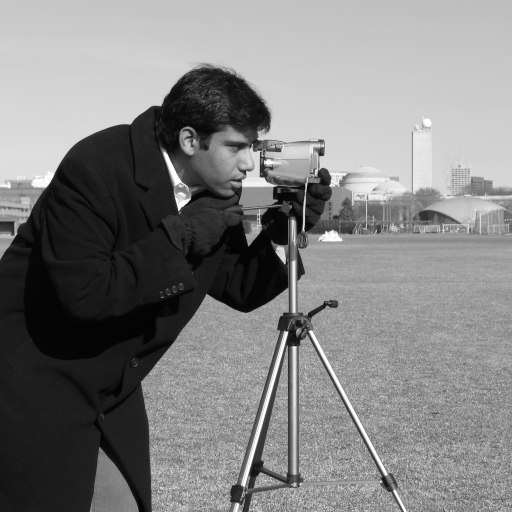

In [23]:
from skimage import data
from PIL import Image

image = data.camera()
print("Image Shape :", image.shape)

print("Height :", image.shape[0])

print("Width :", image.shape[1])

print("Data Type :", image.dtype)

print("\n")

Image.fromarray(image).save(
    "forensic_image.png"
)

Image.open("forensic_image.png")



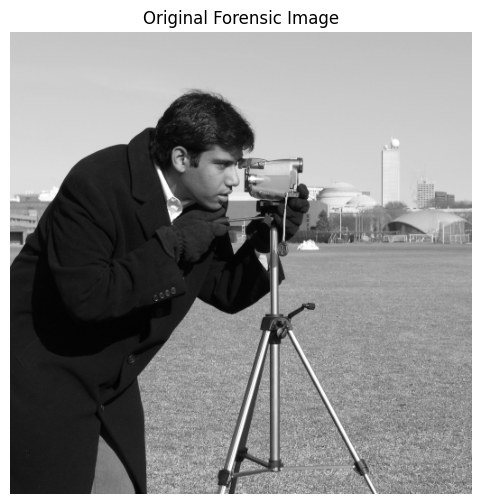

In [24]:
plt.figure(figsize=(6,6))

plt.imshow(image, cmap='gray')

plt.title("Original Forensic Image")

plt.axis('off')

plt.show()

## Let's Create Synthetic Test Image

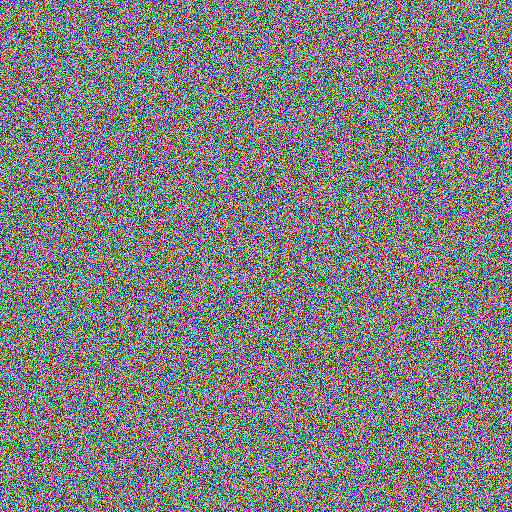

In [25]:
synthetic = np.random.randint(
    0,
    255,
    (512,512,3),
    dtype=np.uint8
)

Image.fromarray(synthetic).save(
    "synthetic_image.png"
)

Image.open("synthetic_image.png")

# SARG04 Protocol

SARG04 is a Quantum Key Distribution protocol.

Participants:

- Alice (Sender)
- Bob (Receiver)

Goal:

Generate a shared secret key securely.

The generated key will later be used to encrypt forensic watermark information.

## Define SARG04 States

In [30]:
states = [

    '0',

    '1',

    '+',

    '-'

]
print(states)

['0', '1', '+', '-']


## State Pair Generation

In [31]:
state_pairs = [

    ('0','+'),

    ('0','-'),

    ('1','+'),

    ('1','-')

]
print(state_pairs)

[('0', '+'), ('0', '-'), ('1', '+'), ('1', '-')]


# Alice Generates Random States

In [32]:
num_bits = 20

alice_states = []

for i in range(num_bits):

    alice_states.append(
        random.choice(states)
    )

alice_states

['0',
 '+',
 '0',
 '0',
 '0',
 '+',
 '-',
 '0',
 '0',
 '0',
 '1',
 '-',
 '1',
 '-',
 '1',
 '-',
 '1',
 '+',
 '1',
 '0']

# Bob Generates Measurements

In [33]:
bob_measurements = []

for i in range(num_bits):

    bob_measurements.append(
        random.choice(states)
    )

bob_measurements

['+',
 '+',
 '-',
 '1',
 '-',
 '-',
 '0',
 '1',
 '0',
 '-',
 '1',
 '+',
 '+',
 '0',
 '0',
 '+',
 '1',
 '0',
 '0',
 '0']

# SARG04 State Pair Selection

In [34]:
selected_pairs = []

for i in range(num_bits):

    selected_pairs.append(
        random.choice(state_pairs)
    )

selected_pairs

[('1', '+'),
 ('1', '+'),
 ('1', '+'),
 ('1', '-'),
 ('0', '-'),
 ('1', '-'),
 ('0', '+'),
 ('1', '-'),
 ('0', '-'),
 ('1', '+'),
 ('0', '+'),
 ('1', '-'),
 ('0', '+'),
 ('1', '-'),
 ('1', '-'),
 ('0', '-'),
 ('0', '+'),
 ('0', '+'),
 ('0', '+'),
 ('0', '-')]

# Shared Key Generation

In [35]:
shared_key = []

for i in range(num_bits):

    if bob_measurements[i] in selected_pairs[i]:

        if alice_states[i] in ['0','+']:

            shared_key.append('0')

        else:

            shared_key.append('1')

generated_key = ''.join(shared_key)

generated_key

'000001001010'

# Final Shared Key

In [36]:
print("Generated Shared Key:")

print(generated_key)

print()

print("Key Length:")

print(len(generated_key))

Generated Shared Key:
000001001010

Key Length:
12


# Visualize Key Generation

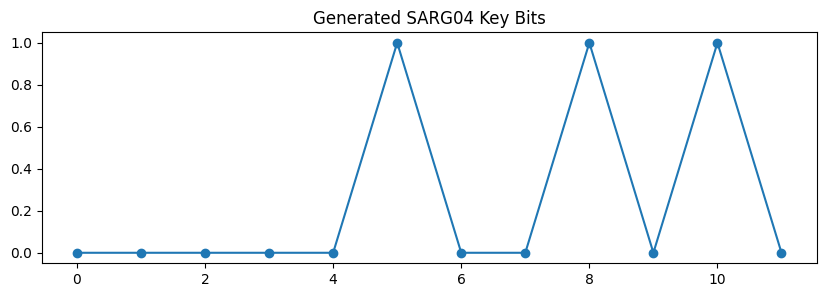

In [38]:
plt.figure(figsize=(10,3))

plt.title(
    "Generated SARG04 Key Bits"
)

plt.plot(
    [int(bit) for bit in generated_key],
    marker='o'
)

plt.show()

# Secure Transmission Scenario
ALICE → BOB TRANSMISSION

In [41]:
alice_key = generated_key

bob_key = generated_key

print("Alice Generated Key:")
print(alice_key)

print("\nBob Received Key:")
print(bob_key)

if alice_key == bob_key:

    print("\nAuthentication Status: SUCCESS")

    print("No Tampering Detected")

else:

    print("\nAuthentication Status: FAILED")

    print("Tampering Detected")

Alice Generated Key:
000001001010

Bob Received Key:
000001001010

Authentication Status: SUCCESS
No Tampering Detected


# Watermark Creation

A forensic watermark is created to store authentication information.

The watermark may contain:

- Case ID
- Timestamp
- Owner Information
- Authentication Code

The watermark will be encrypted using the SARG04-generated key before embedding.

In [42]:
watermark = """
CASE_ID: 2026-001
OWNER: FORENSIC LAB
STATUS: AUTHENTIC
"""

print("Original Watermark:\n")

print(watermark)


Original Watermark:


CASE_ID: 2026-001
OWNER: FORENSIC LAB
STATUS: AUTHENTIC



## Watermark Information Analysis

In [43]:
print("Watermark Length:")

print(len(watermark))

print()

print("Watermark Characters:")

print(list(watermark[:20]))

Watermark Length:
57

Watermark Characters:
['\n', 'C', 'A', 'S', 'E', '_', 'I', 'D', ':', ' ', '2', '0', '2', '6', '-', '0', '0', '1', '\n', 'O']


## Convert Watermark to Binary

In [44]:
binary_watermark = ''.join(
    format(ord(char), '08b')
    for char in watermark
)

print(binary_watermark[:200])

00001010010000110100000101010011010001010101111101001001010001000011101000100000001100100011000000110010001101100010110100110000001100000011000100001010010011110101011101001110010001010101001000111010


"Each character is converted into 8-bit binary format.

This binary data will later be embedded into the forensic image."

# Encrypt Watermark Using Generated Shared Key

In [45]:
def encrypt_watermark(message, key):

    encrypted = ""

    for i in range(len(message)):

        encrypted += chr(
            ord(message[i])
            ^
            ord(key[i % len(key)])
        )

    return encrypted

In [46]:
encrypted_watermark = encrypt_watermark(
    watermark,
    generated_key
)

print("Encrypted Watermark:\n")

print(encrypted_watermark)

Encrypted Watermark:

:sqcunyt    :f~tb
vbt~cxs|qr:cdpdeb
qedxu~eys;


## Verify Watermark Has Been Encrypted

In [49]:
print("Original Length :",
      len(watermark))

print()

print("Encrypted Length :",
      len(encrypted_watermark))

Original Length : 57

Encrypted Length : 57


In [50]:
print("========== BEFORE ENCRYPTION ==========\n")

print(watermark)

print("\n")

print("========== AFTER ENCRYPTION ==========\n")

print(encrypted_watermark)

========== BEFORE ENCRYPTION ==========


CASE_ID: 2026-001
OWNER: FORENSIC LAB
STATUS: AUTHENTIC



========== AFTER ENCRYPTION ==========

:sqcunyt    :f~tb
vbt~cxs|qr:cdpdeb
qedxu~eys;


# Secure Watermark Transfer

Alice encrypts the forensic watermark using the SARG04 shared key.

The encrypted watermark is then prepared for image embedding.

In [55]:
watermark_created = True
watermark_encrypted = True
watermark_ready_for_embedding = True

print(f"Alice Created Watermark: {watermark_created}")
print(f"Alice Encrypted Watermark: {watermark_encrypted}")
print(f"Watermark Ready For Image Embedding: {watermark_ready_for_embedding}")

if watermark_created and watermark_encrypted and watermark_ready_for_embedding:
    transmission_status = True
    print(f"\nSecure Watermark Transfer Status: SUCCESS")
else:
    transmission_status = False
    print(f"\nSecure Watermark Transfer Status: FAILED")

Alice Created Watermark: True
Alice Encrypted Watermark: True
Watermark Ready For Image Embedding: True

Secure Watermark Transfer Status: SUCCESS


# DWT Watermark Embedding

Discrete Wavelet Transform (DWT) is used to embed the encrypted watermark into the forensic image.

Advantages:

- Better imperceptibility
- Better robustness
- Suitable for forensic authentication

In [59]:
!pip install PyWavelets

import pywt

## Now Load Original Forensic Image

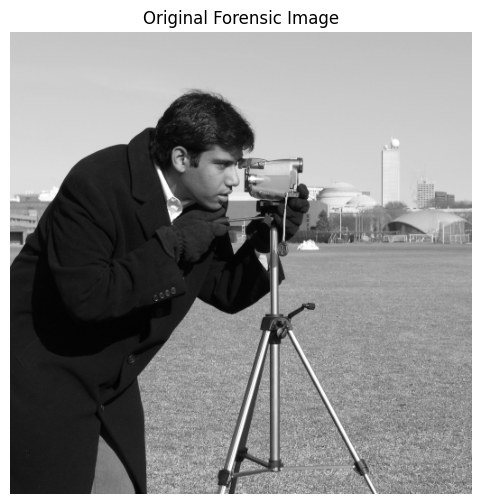

In [60]:
original_image = np.array(
    Image.open("forensic_image.png")
)

plt.figure(figsize=(6,6))

plt.imshow(
    original_image,
    cmap='gray'
)

plt.title(
    "Original Forensic Image"
)

plt.axis('off')

plt.show()

# Apply DWT

The image is decomposed into four frequency bands:

- LL (Approximation)
- LH (Horizontal)
- HL (Vertical)
- HH (Diagonal)

In [61]:
LL, (LH, HL, HH) = pywt.dwt2(
    original_image,
    'haar'
)

## Now display the DWT Components

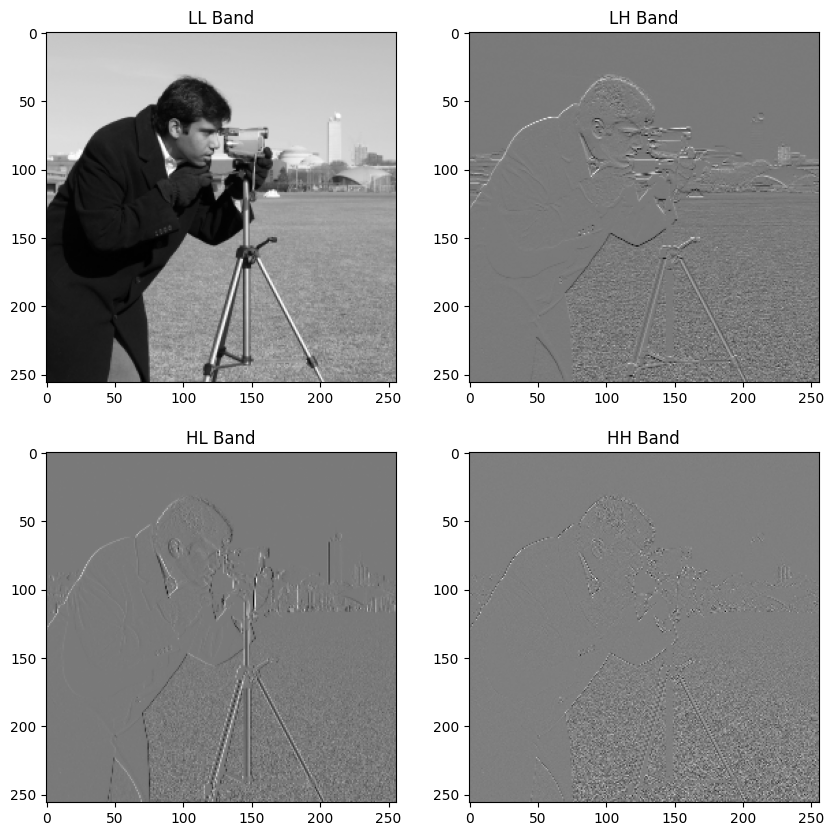

In [62]:
fig, ax = plt.subplots(
    2,
    2,
    figsize=(10,10)
)

ax[0,0].imshow(LL,cmap='gray')
ax[0,0].set_title("LL Band")

ax[0,1].imshow(LH,cmap='gray')
ax[0,1].set_title("LH Band")

ax[1,0].imshow(HL,cmap='gray')
ax[1,0].set_title("HL Band")

ax[1,1].imshow(HH,cmap='gray')
ax[1,1].set_title("HH Band")

plt.show()

## Convert Encrypted Watermark to Binary

In [63]:
watermark_bits = ''.join(

    format(ord(char),'08b')

    for char in encrypted_watermark

)

print(
    "Total Watermark Bits:",
    len(watermark_bits)
)

Total Watermark Bits: 456


# Watermark Embedding

The encrypted watermark bits are embedded into the HH frequency band.

In [64]:
HH_embedded = HH.copy()

index = 0

for i in range(HH_embedded.shape[0]):

    for j in range(HH_embedded.shape[1]):

        if index < len(watermark_bits):

            bit = int(
                watermark_bits[index]
            )

            HH_embedded[i,j] += bit

            index += 1

# Inverse DWT Reconstruction

In [65]:
watermarked_image = pywt.idwt2(

    (
        LL,
        (
            LH,
            HL,
            HH_embedded
        )
    ),

    'haar'
)

watermarked_image = np.clip(
    watermarked_image,
    0,
    255
)

watermarked_image = watermarked_image.astype(
    np.uint8
)

## Now save the Watermarked Image

In [66]:
Image.fromarray(
    watermarked_image
).save(
    "watermarked_image.png"
)

## Display Original vs Watermarked

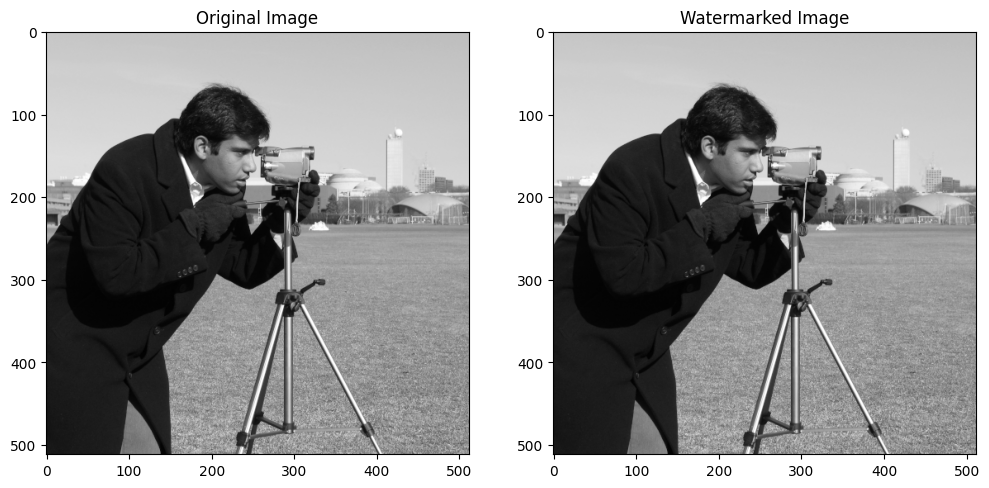

In [67]:
fig, ax = plt.subplots(
    1,
    2,
    figsize=(12,6)
)

ax[0].imshow(
    original_image,
    cmap='gray'
)

ax[0].set_title(
    "Original Image"
)

ax[1].imshow(
    watermarked_image,
    cmap='gray'
)

ax[1].set_title(
    "Watermarked Image"
)

plt.show()

# Difference Image
Let's see the difference.

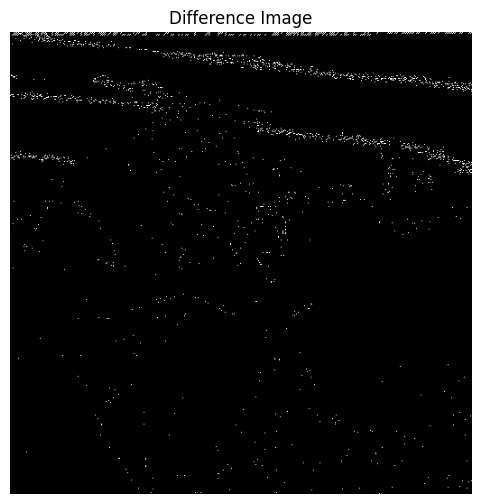

In [68]:
difference = cv2.absdiff(

    original_image,

    watermarked_image

)

plt.figure(
    figsize=(6,6)
)

plt.imshow(
    difference,
    cmap='gray'
)

plt.title(
    "Difference Image"
)

plt.axis('off')

plt.show()

# Peak Signal-to-Noise Ratio
Now Let's caluclate the PSNR


In [69]:
mse = np.mean(

    (
        original_image -

        watermarked_image

    ) ** 2

)

psnr = 20 * np.log10(

    255.0 /

    np.sqrt(mse)

)

print("PSNR =", psnr)

PSNR = 68.63891736732596


##Structural Similarity Index Measure

Now let's caluclate the SSIM


In [70]:
from skimage.metrics import structural_similarity

ssim_score = structural_similarity(

    original_image,

    watermarked_image

)

print(
    "SSIM =",
    ssim_score
)

SSIM = 0.9999084101984418


## Quality Assessment

In [71]:
print("Image Quality Analysis")

print()

print("PSNR :", psnr)

print()

print("SSIM :", ssim_score)

if psnr > 40 and ssim_score > 0.95:

    print()

    print(
        "Embedding Successful"
    )

    print(
        "Visual Quality Preserved"
    )

else:

    print()

    print(
        "Quality Degradation Detected"
    )

Image Quality Analysis

PSNR : 68.63891736732596

SSIM : 0.9999084101984418

Embedding Successful
Visual Quality Preserved


## Now Bob Receives Watermarked Image

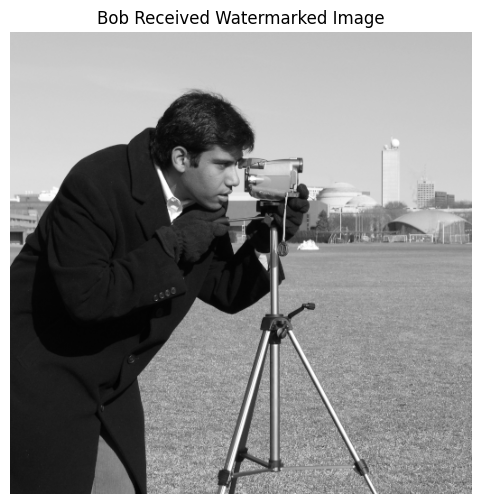

In [72]:
received_image = np.array(
    Image.open("watermarked_image.png")
)

plt.figure(figsize=(6,6))

plt.imshow(
    received_image,
    cmap='gray'
)

plt.title(
    "Bob Received Watermarked Image"
)

plt.axis('off')

plt.show()

## Apply DWT to Received Image

In [73]:
LL_r, (LH_r, HL_r, HH_r) = pywt.dwt2(
    received_image,
    'haar'
)

## Watermark Bit Extraction

In [74]:
extracted_bits = ""

bit_count = len(watermark_bits)

index = 0

for i in range(HH_r.shape[0]):

    for j in range(HH_r.shape[1]):

        if index < bit_count:

            bit = int(round(HH_r[i,j])) % 2

            extracted_bits += str(bit)

            index += 1

## Binary to Text Conversion

In [78]:
encrypted_extracted = ""

for i in range(0, len(extracted_bits), 8):

    byte = extracted_bits[i:i+8]

    if len(byte) == 8:

        encrypted_extracted += chr(
            int(byte,2)
        )


print("Extracted Encrypted Watermark:\n")

print(encrypted_extracted)

Extracted Encrypted Watermark:

òsQkØ¼4®S+pýlÀUI.Þ_zäg·¦ÇË\ÿ>ay¥¿-5¼®üÆ¹°Ôý$òsWµ


# Watermark Decryption Using SARG04 Key

In [80]:
def decrypt_watermark(message,key):

    decrypted = ""

    for i in range(len(message)):

        decrypted += chr(

            ord(message[i])

            ^

            ord(key[i % len(key)])

        )

    return decrypted

##Recover original watermark

In [89]:
recovered_watermark = decrypt_watermark(

    encrypted_watermark,

    generated_key

)

print("Recovered Watermark:\n")

print(recovered_watermark)

Recovered Watermark:


CASE_ID: 2026-001
OWNER: FORENSIC LAB
STATUS: AUTHENTIC



In [92]:
print("===== ORIGINAL WATERMARK =====\n")

print(encrypted_watermark)

print()

print("===== RECOVERED WATERMARK =====\n")

print(recovered_watermark)

===== ORIGINAL WATERMARK =====

:sqcunyt    :f~tb
vbt~cxs|qr:cdpdeb
qedxu~eys;

===== RECOVERED WATERMARK =====


CASE_ID: 2026-001
OWNER: FORENSIC LAB
STATUS: AUTHENTIC



# Authentication Verification

In [96]:
if watermark == recovered_watermark:

    print(
        "AUTHENTICATION SUCCESSFUL"
    )

    print(
        "Image Integrity Preserved"
    )

else:

    print(
        "AUTHENTICATION FAILED"
    )

    print(
        "Possible Tampering Detected"
    )

AUTHENTICATION SUCCESSFUL
Image Integrity Preserved


##Watermark Similarity Score

In [102]:
matches = 0

for i in range(

    min(

        len(watermark),

        len(recovered_watermark)

    )

):

    if watermark[i] == recovered_watermark[i]:

        matches += 1

similarity = (

    matches /

    len(watermark)

) * 100

print(

    "Watermark Similarity:",

    similarity,

    "%"
)

if similarity >= 95:

    status = "AUTHENTIC"

else:

    status = "TAMPERED"

print(f"\nFinal Decision: {status}")

Watermark Similarity: 100.0 %

Final Decision: AUTHENTIC


#Tampering Attack Simulation & Detection